# Subgraph verification: does RemoteGraph actually control subgraphs?

`researcher`/`coder`/`reviewer` are flat ReAct agents, so they can't prove whether
`RemoteGraph` actually gives central control *inside* a remote graph that contains
a subgraph -- only that it can call the graph as a whole. This notebook deploys a
small, deterministic, LLM-free graph (`agents/subgraph_demo`) that has a real
subgraph node, and checks three things against a live backend:

1. `stream_subgraphs=True` surfaces events from *inside* the subgraph, not just the
   subgraph node's aggregate result.
2. `interrupt_before=["inner"]` actually pauses the run *before* the subgraph node
   runs (`state.next == ("inner",)`), and resuming continues correctly.
3. The same behavior holds through the actual `RemoteGraph` class (what
   `agents/supervisor/graph.py` uses), not just the raw `langgraph_sdk` client.

Backend: `langgraph-platform` (`langgraph dev`, no Docker, no LLM calls needed).

In [1]:
import sys

sys.path.insert(0, "/Users/jyje/repo/jyje/pilot-langchain-remotegraph")

from remotegraph.backends.langgraph_platform import LangGraphPlatformBackend

backend = LangGraphPlatformBackend()
backend.deploy({
    "researcher": "agents/researcher/graph.py:graph",
    "coder": "agents/coder/graph.py:graph",
    "reviewer": "agents/reviewer/graph.py:graph",
    "subgraph_demo": "agents/subgraph_demo/graph.py:graph",
})
backend.up()
print(backend.status())


running


### `subgraph_demo`'s structure, with `inner` expanded

`prepare -> inner (a compiled subgraph) -> finalize`. `xray=True` expands `inner` to show its own internal node (`shout`) instead of collapsing it into a single opaque box.

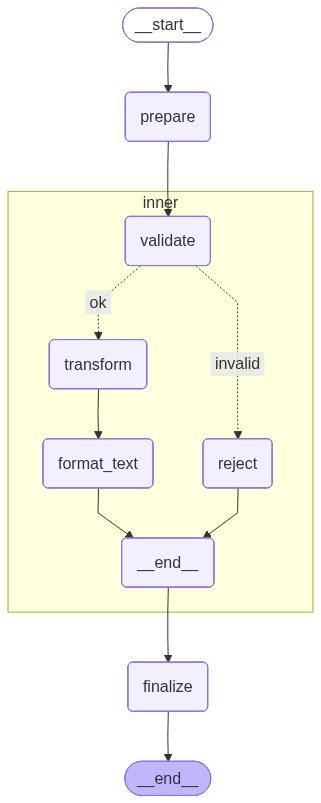

In [2]:
from IPython.display import Image

from agents.subgraph_demo.graph import graph as subgraph_demo_graph

Image(subgraph_demo_graph.get_graph(xray=True).draw_mermaid_png())


## 1. `stream_subgraphs=True`: can we see inside the subgraph?

`agents/subgraph_demo` is now `prepare -> inner (a subgraph: validate -> {transform -> format_text | reject}) -> finalize`. Without `stream_subgraphs=True` you'd only ever see `inner`'s aggregate result. With it, the subgraph's own internal node updates should appear as separately namespaced events -- including which branch (`transform`/`format_text` vs `reject`) was actually taken, for both a normal and an empty input.

In [3]:
import time

from langgraph_sdk import get_sync_client

client = get_sync_client(url=backend.base_url)

for _attempt in range(10):
    try:
        client.assistants.search()
        break
    except Exception:
        time.sleep(2)

for label, text in [("non-empty", "hello"), ("empty", "   ")]:
    print(f"--- input: {label!r} ---")
    thread = client.threads.create()
    for chunk in client.runs.stream(
        thread["thread_id"],
        "subgraph_demo",
        input={"text": text},
        stream_mode=["updates"],
        stream_subgraphs=True,
    ):
        print(chunk.event, "->", chunk.data)
    print()


--- input: 'non-empty' ---


metadata -> {'run_id': '019eec26-070c-7f93-bc0d-f9acd357bfbb', 'attempt': 1}
updates -> {'prepare': {'text': '[prepared] hello'}}
updates|inner:fddc06a1-9249-4426-9d8b-f7e4375863f7 -> {'validate': {'text': '[prepared] hello'}}
updates|inner:fddc06a1-9249-4426-9d8b-f7e4375863f7 -> {'transform': {'text': 'HELLO [PREPARED]'}}
updates|inner:fddc06a1-9249-4426-9d8b-f7e4375863f7 -> {'format_text': {'text': '[HELLO [PREPARED]]'}}
updates -> {'inner': {'text': '[HELLO [PREPARED]]'}}
updates -> {'finalize': {'text': '[HELLO [PREPARED]] [finalized]'}}

--- input: 'empty' ---


metadata -> {'run_id': '019eec26-0ab9-7003-b255-9c532cbbd809', 'attempt': 1}
updates -> {'prepare': {'text': '[prepared]    '}}
updates|inner:11261985-4edb-ddcd-3131-5fdf09b6ec3a -> {'validate': {'text': '[prepared]    '}}
updates|inner:11261985-4edb-ddcd-3131-5fdf09b6ec3a -> {'reject': {'text': '[rejected: empty input]'}}
updates -> {'inner': {'text': '[rejected: empty input]'}}
updates -> {'finalize': {'text': '[rejected: empty input] [finalized]'}}



## 2. `interrupt_before=["inner"]`: does it actually pause before the subgraph?

If subgraph control is real, the run should stop with `state.next == ("inner",)` *before* the subgraph's `validate`/`transform`/`format_text` nodes ever execute -- `state.values["text"]` should still just be the `prepare`d text.

In [4]:
thread2 = client.threads.create()
tid = thread2["thread_id"]

for chunk in client.runs.stream(
    tid,
    "subgraph_demo",
    input={"text": "world"},
    stream_mode=["updates"],
    interrupt_before=["inner"],
):
    print(chunk.event, "->", chunk.data)

state = client.threads.get_state(tid)
print()
print("next:", state["next"])
print("values:", state["values"])
assert state["next"] == ["inner"]
assert state["values"]["text"] == "[prepared] world"  # subgraph hasn't run yet


metadata -> {'run_id': '019eec26-0eb8-7cd0-8f9e-4e1f41b6578c', 'attempt': 1}
updates -> {'prepare': {'text': '[prepared] world'}}
updates -> {'__interrupt__': []}

next: ['inner']
values: {'text': '[prepared] world'}


## 3. Resume past the interrupt -- does it continue into the subgraph correctly?

In [5]:
for chunk in client.runs.stream(tid, "subgraph_demo", input=None, stream_mode=["updates"]):
    print(chunk.event, "->", chunk.data)

final_state = client.threads.get_state(tid)
print()
print("next:", final_state["next"])
print("values:", final_state["values"])
assert final_state["values"]["text"] == "[WORLD [PREPARED]] [finalized]"


metadata -> {'run_id': '019eec26-12b1-7f72-885c-758758a39b22', 'attempt': 1}
updates -> {'inner': {'text': '[WORLD [PREPARED]]'}}
updates -> {'finalize': {'text': '[WORLD [PREPARED]] [finalized]'}}

next: []
values: {'text': '[WORLD [PREPARED]] [finalized]'}


## 4. Same thing through `RemoteGraph` itself

This is the class `agents/supervisor/graph.py` actually uses -- not the raw SDK
client. If this works the same way, the supervisor pattern genuinely supports
subgraph-level control, not just whole-graph calls.

In [6]:
import uuid

from langgraph.pregel.remote import RemoteGraph

remote = RemoteGraph("subgraph_demo", url=backend.base_url)
config = {"configurable": {"thread_id": str(uuid.uuid4())}}

paused = remote.invoke({"text": "via RemoteGraph"}, config=config, interrupt_before=["inner"])
print("paused result:", paused)

state = remote.get_state(config)
print("next:", state.next)
print("values:", state.values)
assert state.next == ("inner",)

final = remote.invoke(None, config=config)
print("final:", final)
assert final["text"] == "[REMOTEGRAPH VIA [PREPARED]] [finalized]"


paused result: {'text': '[prepared] via RemoteGraph'}
next: ('inner',)
values: {'text': '[prepared] via RemoteGraph'}


final: {'text': '[REMOTEGRAPH VIA [PREPARED]] [finalized]'}


## 5. Teardown

In [7]:
backend.down()
print(backend.status())


stopped
